### TWWWWO2 Layer Perceptron (Feed-Forward Neural Net) 

In [1]:
import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt

### Activation Funs

In [2]:
def linear(H):
    return H

def Sigmoid(H):
    return 1/(1+np.exp(-H))

def ReLU(H):
    return H if (H>0) else 0

def softmax(H):
    eH = np.exp(H)
    return eH/eH.sum(axis=1, keepdims=True)

### Useful Func (utils)

In [ ]:
def one_hot_encode(y):
    N=len(y)
    K=len(set(y))
    Y= np.zeros((N,K))
    for i in range(N):
        Y[i,y[i]] = 1
    return Y

def cross_entropy(Y,P_hat):
    return -np.sum(Y*np.log(P_hat))

def accuracy(y,y_hat):
    return np.mean(y==y_hat)

In [9]:
y_sample=np.array([0,1,2,0,0,2,1])
print(one_hot_encode(y_sample))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


### Shallow ANN Class

In [ ]:
class Shallow_ANN():

    def fit(self,X,y,neurons=6,eta=1e-3,epochs=1e3,show_curve=True):
        epochs = int(epochs)
        N, D = X.shape
        Y = one_hot_encode(y)
        K = Y.shape[1]

        # Initialize Weights and Biases
        self.W = {l:np.random.randn(M[0],M[1]) for l,M in enumerate(zip([D,neurons],[neurons,K]),1)}
        self.B = {l:np.random.randn(M) for l, M in enumerate([neurons,K],1)}

        # Define Activations
        self.a = {1:np.tanh,2:softmax}

        #Loss Container
        J = np.zeros(epochs)

        # Gradient Descent Progression
        for epoch in range(epochs):
            self.__forward__(X)
            J[epoch] = cross_entropy(Y,self.Z[2])
            
            # Weight Update Rules for Layer 2
            self.W[2] -= eta*(1/N)*self.Z[1].T@(self.Z[2]-Y)
            self.B[2] -= eta*(1/N)*(self.Z[2]-Y).sum(axis=0)

            # Weight Update Rules for Layer 1
            self.W[1] -= eta*(1/N)*X.T@((self.Z[2]-Y)@self.W[2].T*(1-self.Z[1]**2)) 
            self.B[1] -= eta*(1/N)*((self.Z[2]-Y)@self.W[2].T*(1-self.Z[1]**2)).sum(axis=0)

        # Show Learning Curve
        if show_curve:
            plt.figure()
            plt.plot(J)
            plt.xlabel("epochs")
            plt.ylabel(r"$\mathcal{J}$")
            plt.title("Training Curse")

    def __forward__(self,X):
        self.Z = {0:X}
        for l in sorted(self.W.keys()):
            self.Z[l] = self.a[l](self.Z[l-1]@self.W[l] + self.B[l])
        
        
    def predict(self,X):
        self.__forward__(X)
        return self.Z[2].argmax(axis=1)

### Implementation of Shallow ANN Class

In [11]:
def main():
  D =2
  K = 3
  N= int(K*1e3)

  X0= np.random.randn((N//K),D) + np.array([2,2])
  X1= np.random.randn((N//K),D) + np.array([0,-2])
  X2= np.random.randn((N//K),D) + np.array([-2,2])
  X=np.vstack((X0,X1,X2))

  y=np.array([0]*(N//K)+ [1]*(N//K)+ [2]*(N//K))

  plt.figure()
  plt.scatter(X[:,0],X[:,1], c=y , s= 5)

  my_ann = Shallow_ANN()
  my_ann.fit(X, y, neurons= 3, eta=1e-2, epochs = 1e4, show_curve= True )
  y_hat =my_ann.predict(X)

  print("Accuracy: ", accuracy(y, y_hat))
  print(my_ann.W)
  print(my_ann.B)

  plt.figure()
  plt.scatter(X[:,0],X[:,1], c=y_hat , s= 5)

Accuracy:  0.963
{1: array([[ 1.14552985, -0.6259552 , -0.82717171],
       [ 2.01102091, -0.29898954,  0.88191486]]), 2: array([[ 1.23913103, -0.81704104,  0.29210992],
       [-2.73763695,  1.58807714,  1.63949695],
       [-0.92194552, -3.0907107 ,  1.6175134 ]])}
{1: array([-0.4093911 ,  0.48726043, -1.06846924]), 2: array([ 0.01868179, -0.54925124,  0.24026621])}


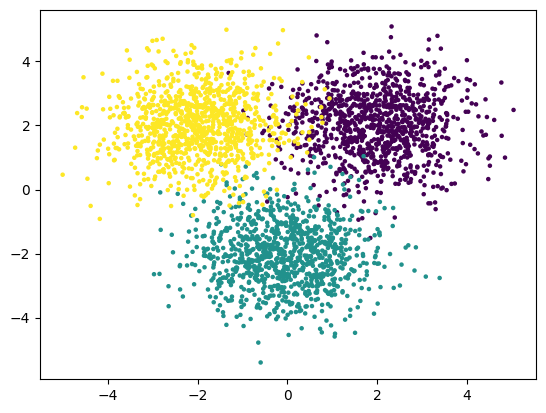

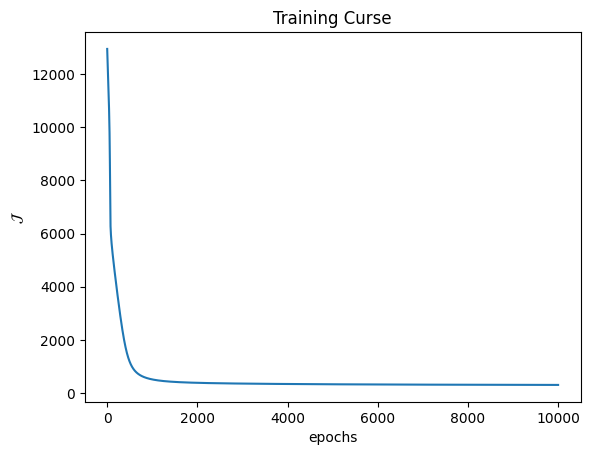

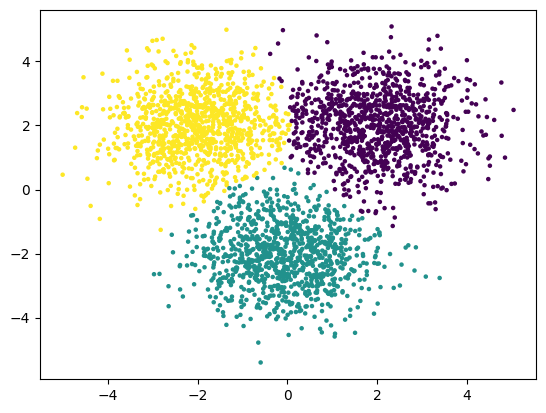

In [12]:
if __name__ == '__main__':
    main()